# Задание 1. Загрузка и профилирование данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных 
df = pd.read_csv("../data/extreme_pollution.csv", sep=";", quotechar='"')

print("Размер данных:", df.shape)
df.head()

Размер данных: (7671, 13)


,id,period,subject,municipality,settlement,oktmo,water_body,indicator,hazard_class,cnt_cases,value_min,value_max,unit
0,1,2008-01-31,Камчатский край,Усть-Камчатский район,п. Козыревск,3.061941e+10,р. Камчатка,Кадмий,2,1,6.0,6.0,ПДК
1,2,2008-01-31,Курганская область,Курган,г. Курган,3.770100e+10,вдхр. Курганское,Марганец,4,1,60.0,60.0,ПДК
2,3,2008-01-31,Московская область,Королёв,г. Королев,4.673400e+10,"ручей, впадающий в реку Клязьму",Нефть и нефтепродукты,3,8,71.0,100.0,ПДК
3,4,2008-01-31,Мурманская область,Печенгский муниципальный район,пгт. Никель,4.751500e+10,р. Колос-Йоки,Никель,3,1,60.0,60.0,ПДК
4,5,2008-01-31,Мурманская область,Городской округ город Мончегорск с подведомств...,г. Мончегорск,4.771500e+10,р. Нюдуай,Водородный показатель (pH),NaN,1,9.9,9.9,pH


In [3]:
# Информация о данных
print("df.info()")
df.info()

print("________________________________________________")

print("\ndf.describe()")
df.describe()

df.info()
<class 'pandas.DataFrame'>
RangeIndex: 7671 entries, 0 to 7670
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            7671 non-null   int64  
 1   period        7671 non-null   str    
 2   subject       7671 non-null   str    
 3   municipality  7324 non-null   str    
 4   settlement    7510 non-null   str    
 5   oktmo         7324 non-null   float64
 6   water_body    7671 non-null   str    
 7   indicator     7671 non-null   str    
 8   hazard_class  5133 non-null   str    
 9   cnt_cases     7671 non-null   int64  
 10  value_min     7670 non-null   float64
 11  value_max     7670 non-null   float64
 12  unit          7671 non-null   str    
dtypes: float64(3), int64(2), str(8)
memory usage: 779.2 KB
________________________________________________

df.describe()


,id,oktmo,cnt_cases,value_min,value_max
count,7671.00000,7.324000e+03,7671.000000,7670.000000,7670.000000
mean,3836.00000,5.238004e+10,1.004563,124.332427,124.348333
std,2214.57129,2.116003e+10,0.144810,934.329858,934.328765
min,1.00000,8.631158e+06,1.000000,0.000000,0.000000
25%,1918.50000,4.472200e+10,1.000000,38.000000,38.000000
50%,3836.00000,5.771900e+10,1.000000,64.000000,64.000000
75%,5753.50000,6.575300e+10,1.000000,96.000000,96.000000
max,7671.00000,9.970100e+10,8.000000,74000.000000,74000.000000


In [4]:
# Пропуски
missing = df.isnull().sum()
print("Пропуски по столбцам:\n", missing[missing > 0].sort_values(ascending=False))

# Диапазоны значений
print("\nДиапазоны (min, max) для числовых столбцов:")
for col in df.select_dtypes(include=[np.number]).columns:
    print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")

Пропуски по столбцам:
 hazard_class    2538
municipality     347
oktmo            347
settlement       161
value_min          1
value_max          1
dtype: int64

Диапазоны (min, max) для числовых столбцов:
id: min = 1, max = 7671
oktmo: min = 8631158.0, max = 99701000001.0
cnt_cases: min = 1, max = 8
value_min: min = 0.0, max = 74000.0
value_max: min = 0.0, max = 74000.0


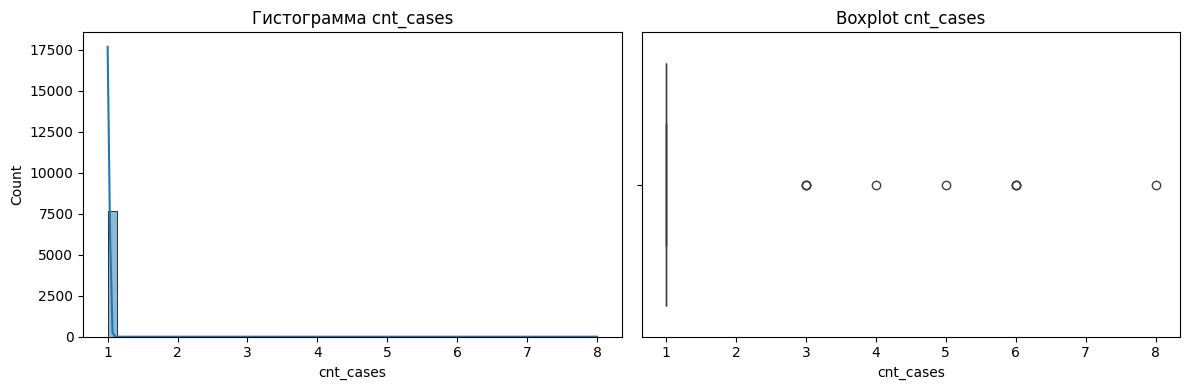

Для cnt_cases: мин=1, макс=8, медиана=1.0


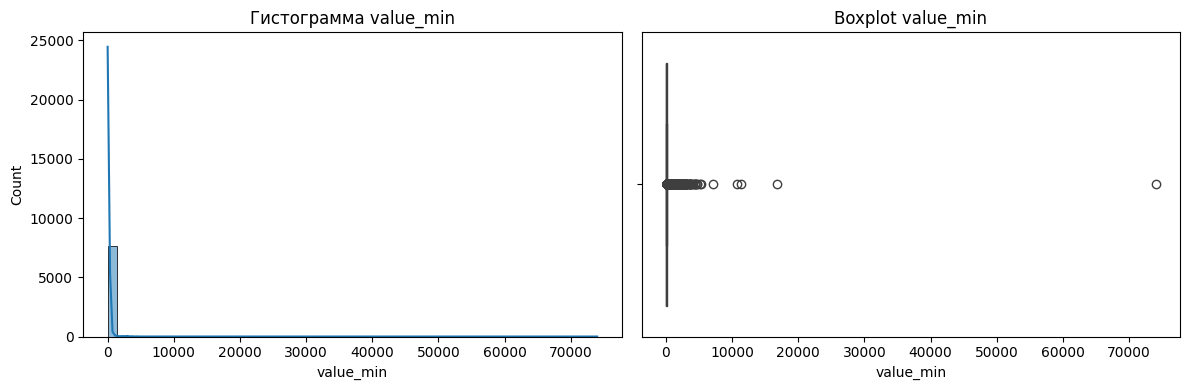

Для value_min: мин=0.0, макс=74000.0, медиана=64.0


In [5]:
# Выбор признаков
features_to_plot = ['cnt_cases', 'value_min']

for col in features_to_plot:
    # Убедимся, что данные числовые
    df[col] = pd.to_numeric(df[col], errors='coerce')
    data = df[col].dropna()
    
    plt.figure(figsize=(12, 4))
    
    # Гистограмма
    plt.subplot(1, 2, 1)
    sns.histplot(data, bins=50, kde=True)
    plt.title(f'Гистограмма {col}')
    
    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data)
    plt.title(f'Boxplot {col}')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Для {col}: мин={data.min()}, макс={data.max()}, медиана={data.median()}")

# Задание 2. Проверка нормальности распределения

In [6]:
from scipy.stats import skew, kurtosis, shapiro, probplot

# Список признаков
features_norm = ['cnt_cases', 'value_min']

for col in features_norm:
    # Удаляем пропуски
    data = df[col].dropna()
    print(f"\n=== Признак: {col} ===")
    print(f"Среднее (mean): {data.mean():.4f}")
    print(f"Медиана (median): {data.median():.4f}")
    print(f"Стандартное отклонение (std): {data.std():.4f}")
    print(f"Коэффициент асимметрии (skewness): {skew(data):.4f}")
    print(f"Коэффициент эксцесса (kurtosis): {kurtosis(data):.4f}")


=== Признак: cnt_cases ===
Среднее (mean): 1.0046
Медиана (median): 1.0000
Стандартное отклонение (std): 0.1448
Коэффициент асимметрии (skewness): 35.6721
Коэффициент эксцесса (kurtosis): 1374.6038

=== Признак: value_min ===
Среднее (mean): 124.3324
Медиана (median): 64.0000
Стандартное отклонение (std): 934.3299
Коэффициент асимметрии (skewness): 65.9798
Коэффициент эксцесса (kurtosis): 5113.7467


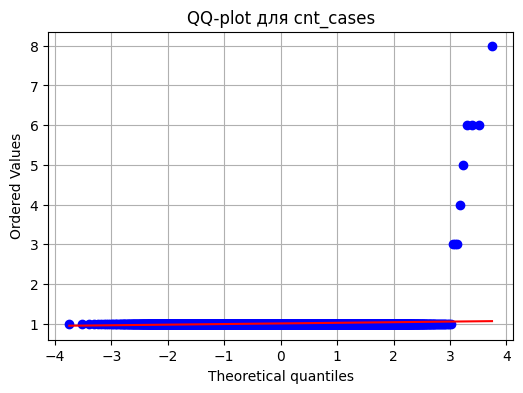

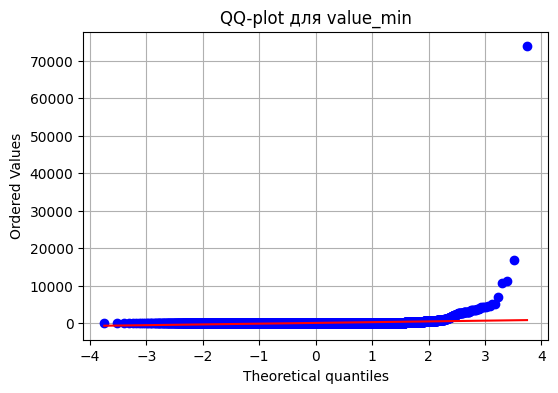

In [7]:
for col in features_norm:
    data = df[col].dropna()
    plt.figure(figsize=(6, 4))
    probplot(data, dist="norm", plot=plt)
    plt.title(f'QQ-plot для {col}')
    plt.grid(True)
    plt.show()

In [20]:
for col in features_norm:
    data = df[col].dropna()
    # Для больших выборок тест может работать долго, но выполним
    stat, p = shapiro(data)
    print(f"\n=== Тест Шапиро-Уилка для {col} ===")
    print(f"Статистика W = {stat:.4f}, p-value = {p:.4e}")
    alpha = 0.05
    if p > alpha:
        print("Не отвергаем H0: распределение соответствует нормальному (p > 0.05)")
    else:
        print("Отвергаем H0: распределение не является нормальным (p <= 0.05)")


=== Тест Шапиро-Уилка для cnt_cases ===
Статистика W = 0.0117, p-value = 2.2643e-107
Отвергаем H0: распределение не является нормальным (p <= 0.05)

=== Тест Шапиро-Уилка для value_min ===
Статистика W = 0.0469, p-value = 1.8914e-106
Отвергаем H0: распределение не является нормальным (p <= 0.05)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7671.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7670.
  res = hypotest_fun_out(*samples, **kwds)


# Задание 3. Обнаружение выбросов статистическими методами

Метод Z-score для cnt_cases:
Всего наблюдений: 7671
Количество выбросов: 9
Процент выбросов: 0.12%
Значения-выбросы: [8 3 5 4 6 3 6 6 3]


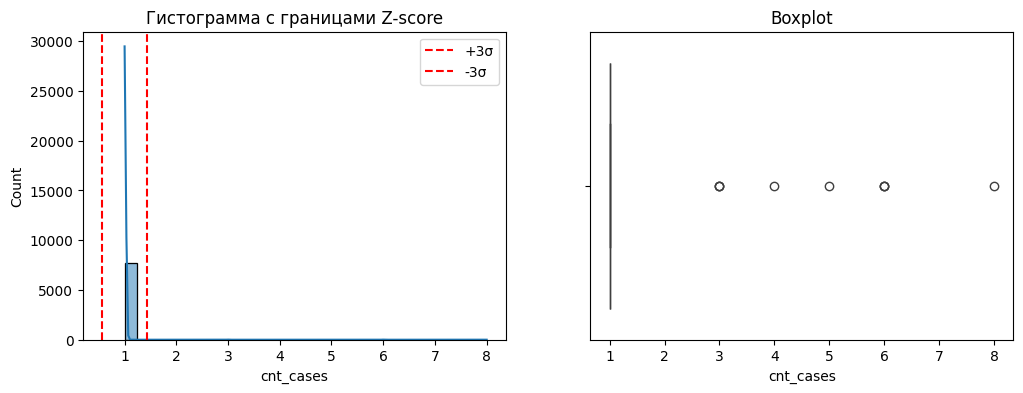

In [9]:
from scipy.stats import zscore

# Признак
col = 'cnt_cases'
data = df[col].dropna()

# Расчёт Z-оценок
z_scores = np.abs(zscore(data))

# Порог
threshold = 3
outliers_z = data[z_scores > threshold]

print(f"Метод Z-score для {col}:")
print(f"Всего наблюдений: {len(data)}")
print(f"Количество выбросов: {len(outliers_z)}")
print(f"Процент выбросов: {100 * len(outliers_z) / len(data):.2f}%")
print(f"Значения-выбросы: {outliers_z.values}")

# Визуализация
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(data, bins=30, kde=True)
plt.axvline(data.mean() + 3*data.std(), color='r', linestyle='--', label='+3σ')
plt.axvline(data.mean() - 3*data.std(), color='r', linestyle='--', label='-3σ')
plt.title('Гистограмма с границами Z-score')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(x=data)
plt.title('Boxplot')
plt.show()

In [10]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = data[(data < lower_bound) | (data > upper_bound)]

print(f"\nМетод IQR для {col}:")
print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
print(f"Нижняя граница = {lower_bound}, верхняя граница = {upper_bound}")
print(f"Количество выбросов: {len(outliers_iqr)}")
print(f"Процент выбросов: {100 * len(outliers_iqr) / len(data):.2f}%")
print(f"Значения-выбросы: {outliers_iqr.values}")


Метод IQR для cnt_cases:
Q1 = 1.0, Q3 = 1.0, IQR = 0.0
Нижняя граница = 1.0, верхняя граница = 1.0
Количество выбросов: 9
Процент выбросов: 0.12%
Значения-выбросы: [8 3 5 4 6 3 6 6 3]


# Задание 4. Метод локальной плотности

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Выбираем признаки
features_knn = ['cnt_cases', 'value_min', 'value_max']  
# Удаляем строки с пропусками
data_knn = df[features_knn].dropna().copy()

# Масштабирование
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_knn)
data_scaled = pd.DataFrame(data_scaled, columns=features_knn, index=data_knn.index)


=== Метрика: euclidean ===
k=5: аномалий = 384 (5.0%)
k=7: аномалий = 383 (5.0%)
k=9: аномалий = 383 (5.0%)
k=10: аномалий = 382 (5.0%)


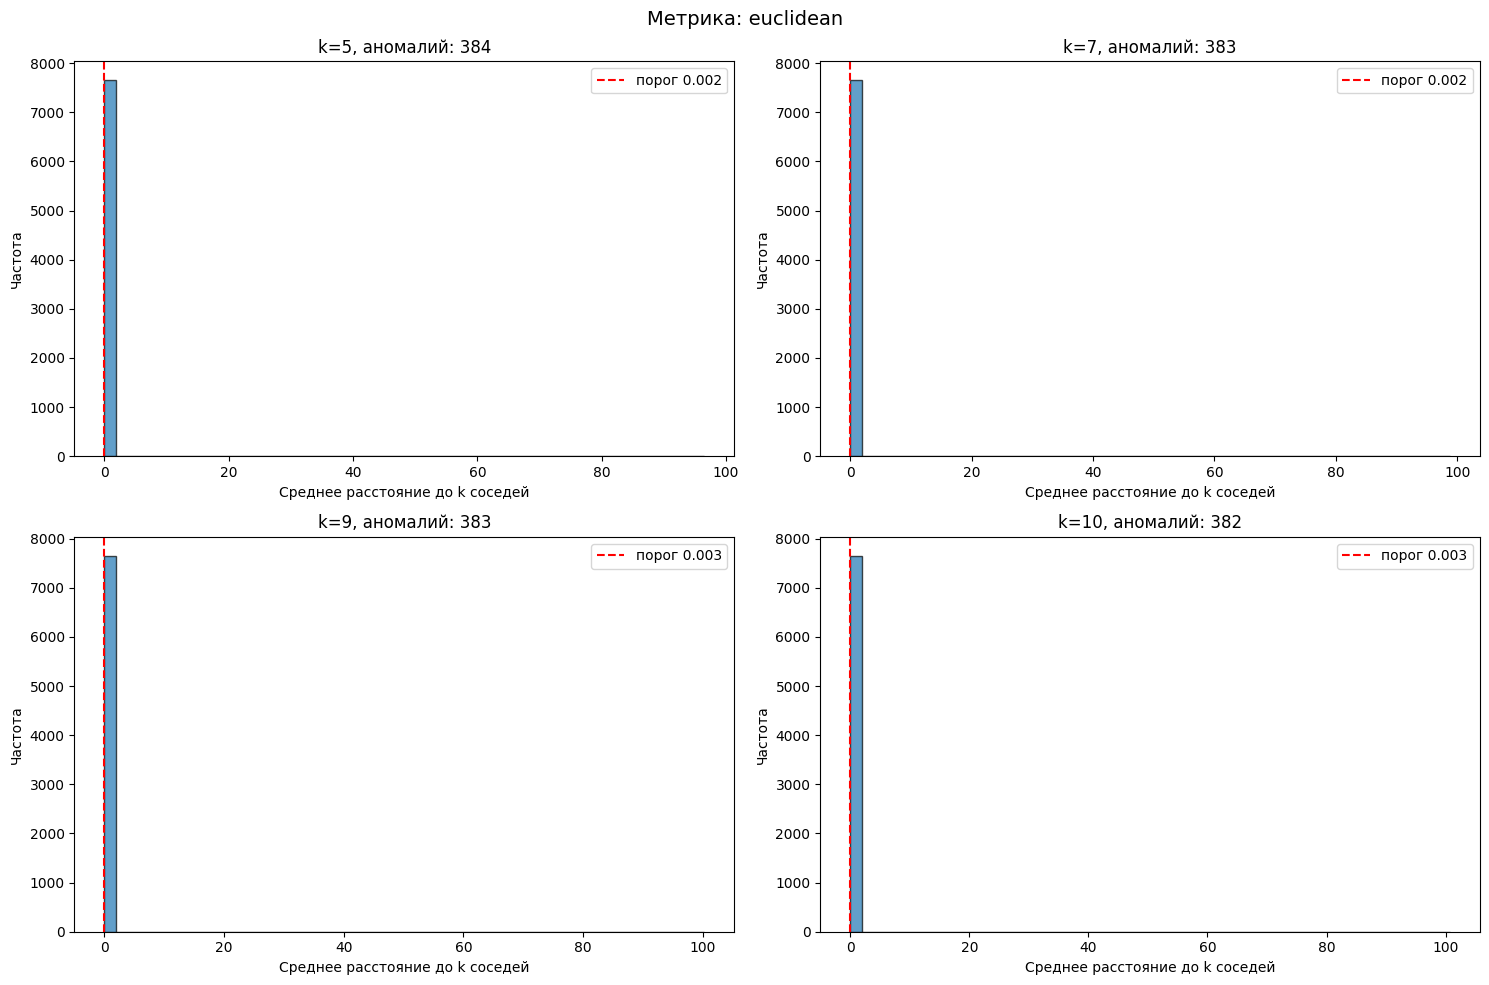


=== Метрика: manhattan ===
k=5: аномалий = 384 (5.0%)
k=7: аномалий = 383 (5.0%)
k=9: аномалий = 383 (5.0%)
k=10: аномалий = 382 (5.0%)


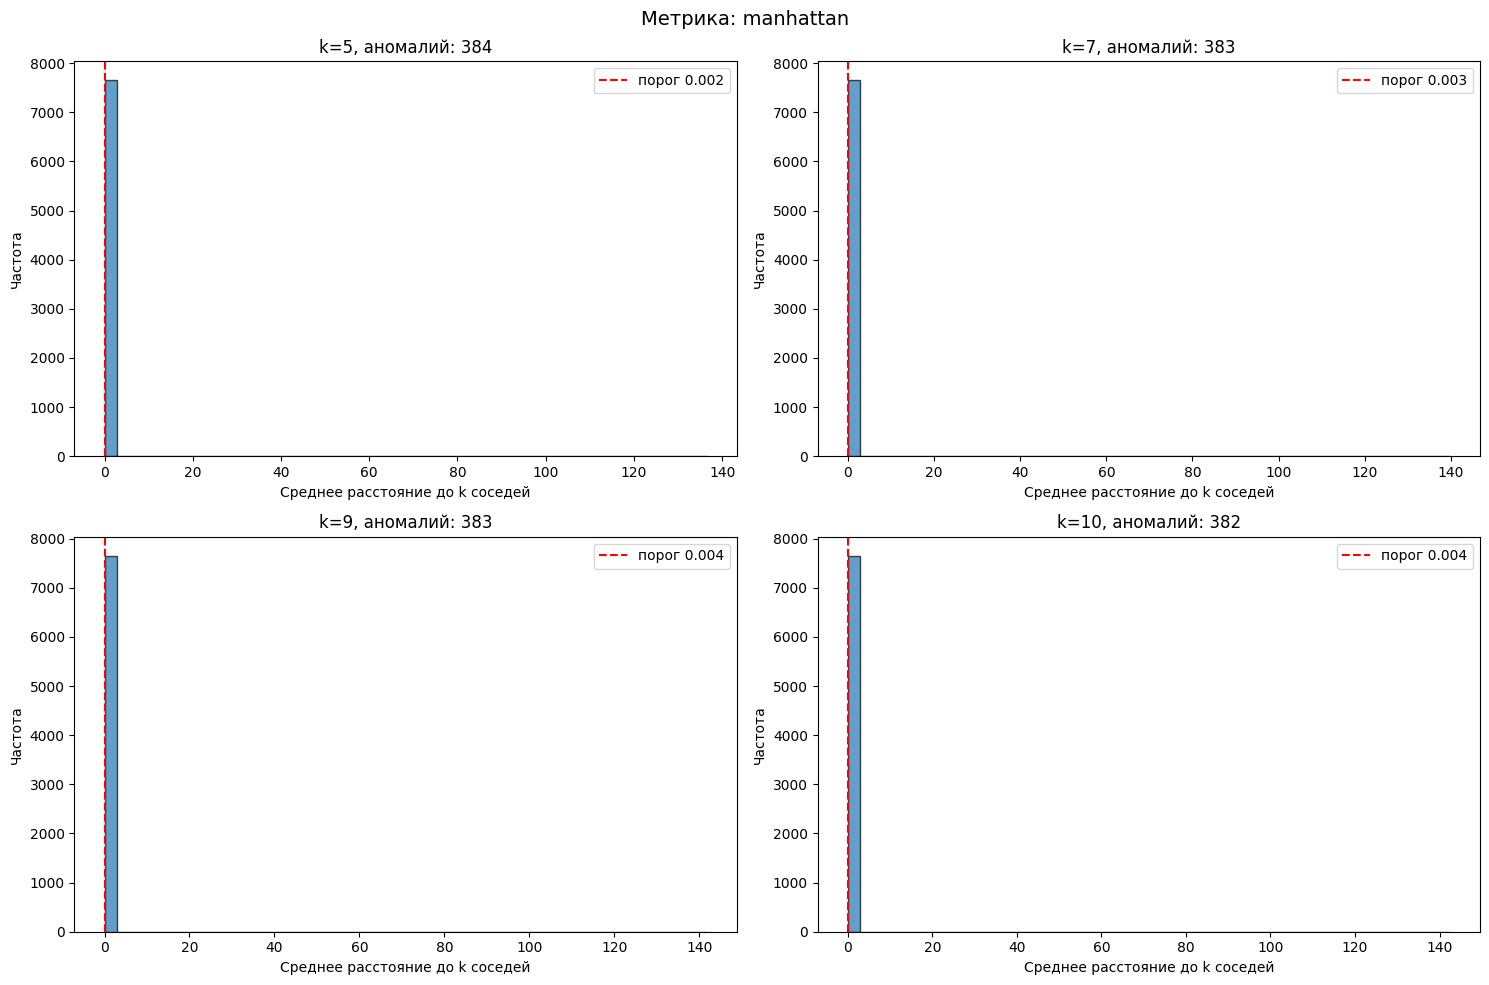

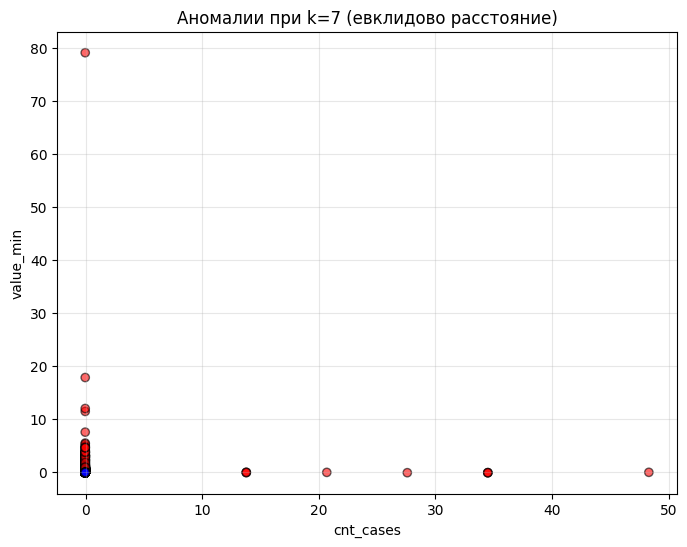

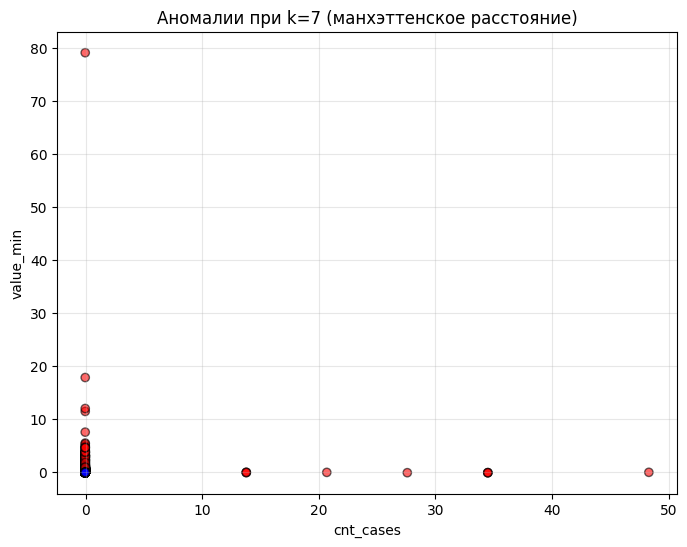

In [21]:
def knn_anomaly_detection(X, k=5, alpha=0.05, metric='euclidean'):
    """
    X: масштабированные признаки
    k: число ближайших соседей
    alpha: доля аномалий (верхние alpha% значений)
    """
    # ищем k+1 соседей (первый сосед - сама точка)
    nbrs = NearestNeighbors(n_neighbors=k+1, metric=metric).fit(X)
    distances, _ = nbrs.kneighbors(X)
    
    # среднее расстояние до k соседей (без учёта самой точки)
    mean_dist = distances[:, 1:].mean(axis=1)
    
    # порог: верхний (1-alpha) процентиль
    threshold = np.percentile(mean_dist, 100 * (1 - alpha))
    outliers = mean_dist > threshold
    return mean_dist, outliers, threshold

k_list = [5, 7, 9, 10]
alpha = 0.05
metrics = ['euclidean', 'manhattan']

for metric in metrics:
    print(f"\n=== Метрика: {metric} ===")
    plt.figure(figsize=(15, 10))
    for i, k in enumerate(k_list, 1):
        mean_dist, outliers, thresh = knn_anomaly_detection(data_scaled, k=k, alpha=alpha, metric=metric)
        print(f"k={k}: аномалий = {np.sum(outliers)} ({100*np.sum(outliers)/len(mean_dist):.1f}%)")
        
        plt.subplot(2, 2, i)
        plt.hist(mean_dist, bins=50, edgecolor='black', alpha=0.7)
        plt.axvline(thresh, color='red', linestyle='--', label=f'порог {thresh:.3f}')
        plt.title(f'k={k}, аномалий: {np.sum(outliers)}')
        plt.xlabel('Среднее расстояние до k соседей')
        plt.ylabel('Частота')
        plt.legend()
    
    plt.suptitle(f'Метрика: {metric}', fontsize=14)
    plt.tight_layout()
    plt.show()

# ----- Визуализация аномалий на плоскости (первые два признака) -----
# Для евклидовой метрики при k=7
mean_dist_e, outliers_e, thresh_e = knn_anomaly_detection(data_scaled, k=7, alpha=alpha, metric='euclidean')

plt.figure(figsize=(8, 6))
plt.scatter(data_scaled.iloc[:, 0], data_scaled.iloc[:, 1], 
            c=['red' if o else 'blue' for o in outliers_e], alpha=0.6, edgecolors='black')
plt.xlabel(features_knn[0])
plt.ylabel(features_knn[1])
plt.title('Аномалии при k=7 (евклидово расстояние)')
plt.grid(alpha=0.3)
plt.show()

# Для манхэттенской метрики при k=7
mean_dist_m, outliers_m, thresh_m = knn_anomaly_detection(data_scaled, k=7, alpha=alpha, metric='manhattan')

plt.figure(figsize=(8, 6))
plt.scatter(data_scaled.iloc[:, 0], data_scaled.iloc[:, 1], 
            c=['red' if o else 'blue' for o in outliers_m], alpha=0.6, edgecolors='black')
plt.xlabel(features_knn[0])
plt.ylabel(features_knn[1])
plt.title('Аномалии при k=7 (манхэттенское расстояние)')
plt.grid(alpha=0.3)
plt.show()